SIMON CIPHER - SIMON is a family of lightweight block ciphers designed by the NSA that utilizes a Feistel network structure to achieve high performance in both hardware and software environments. It is specifically optimized for resource-constrained devices, using simple bitwise operations like AND, XOR, and circular shifts to provide security across various block and key sizes.

Logistic Regression

Dataset Generation for Logistic Regression

In [1]:
import random
import numpy as np
WORD_SIZE = 16
def rotl(x, r):
    return ((x << r) & 0xFFFF) | (x >> (WORD_SIZE - r))
def simon_round(l, r, k):
    f = (rotl(l,1) & rotl(l,8)) ^ rotl(l,2)
    return r ^ f ^ k, l
def key_schedule(key, rounds):
    return [(key >> (i % 16)) & 0xFFFF for i in range(rounds)]
def simon_encrypt(p, key, rounds):
    l = (p >> 16) & 0xFFFF
    r = p & 0xFFFF
    keys = key_schedule(key, rounds)
    for i in range(rounds):
        l, r = simon_round(l, r, keys[i])
    return (l << 16) | r

def int_to_bits(x, bits=32):
    return [int(b) for b in format(x, f'0{bits}b')]

def simon_features(x):
    x1 = ((x << 1) | (x >> 31)) & 0xFFFFFFFF
    x2 = ((x << 2) | (x >> 30)) & 0xFFFFFFFF
    x8 = ((x << 8) | (x >> 24)) & 0xFFFFFFFF

    f = x1 & x8

    features = []
    features += int_to_bits(x)
    features += int_to_bits(x1)
    features += int_to_bits(x2)
    features += int_to_bits(x8)
    features += int_to_bits(f)

    return features

def generate_dataset(samples, rounds, key):

    X = []
    Y = []

    for _ in range(samples):

        p1 = random.getrandbits(32)
        p2 = random.getrandbits(32)

        c1 = simon_encrypt(p1, key, rounds)
        c2 = simon_encrypt(p2, key, rounds)

        dp = p1 ^ p2
        dc = c1 ^ c2

        X.append(simon_features(dp))
        Y.append(int_to_bits(dc))

    return np.array(X), np.array(Y)

# -----------------------------
if __name__ == "__main__":
    key = random.getrandbits(64)
    samples = 20000
    print("Using key:", hex(key))
    for r in range(1, 5):
        print(f"Generating dataset for round {r}")
        X, Y = generate_dataset(samples, r, key)
        np.save(f"best_r{r}_X.npy", X)
        np.save(f"best_r{r}_Y.npy", Y)
        print("Saved:", X.shape, Y.shape)

Using key: 0xc1738822dc2c1ea1
Generating dataset for round 1
Saved: (20000, 160) (20000, 32)
Generating dataset for round 2
Saved: (20000, 160) (20000, 32)
Generating dataset for round 3
Saved: (20000, 160) (20000, 32)
Generating dataset for round 4
Saved: (20000, 160) (20000, 32)


Logistic Regression Model -

Using device: cuda

Round 1 (GPU)
Accuracy: 0.7496 | Hamming: 8.0122

Round 2 (GPU)
Accuracy: 0.4982 | Hamming: 16.0588

Round 3 (GPU)
Accuracy: 0.5001 | Hamming: 15.9975

Round 4 (GPU)
Accuracy: 0.5001 | Hamming: 15.9975


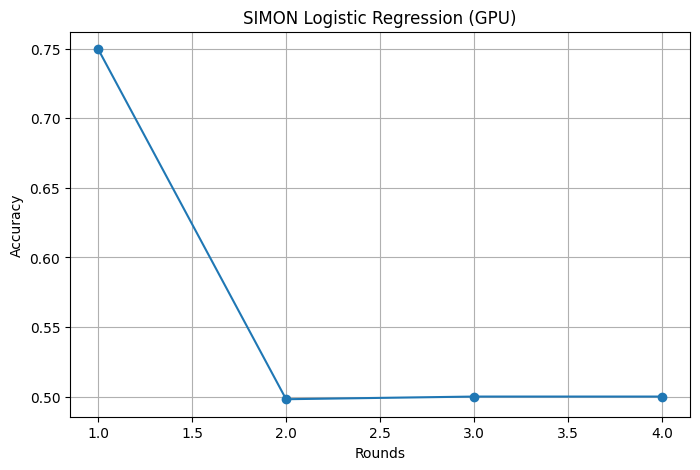

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class LogisticRegressionGPU(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LogisticRegressionGPU, self).__init__()
        # Logistic Regression is essentially a Linear layer followed by Sigmoid
        self.linear = nn.Linear(input_dim, output_dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(self.linear(x))

# 3. TRAIN + EVALUATE FUNCTION
def evaluate_gpu(X, Y):
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.2, random_state=42
    )

    X_train_t = torch.tensor(X_train).float()
    Y_train_t = torch.tensor(Y_train).float()
    X_test_t = torch.tensor(X_test).float().to(device)
    Y_test_t = torch.tensor(Y_test).float().to(device)

    train_loader = DataLoader(TensorDataset(X_train_t, Y_train_t), batch_size=512, shuffle=True)

    input_size = X.shape[1]
    output_size = Y.shape[1]
    model = LogisticRegressionGPU(input_size, output_size).to(device)

    criterion = nn.BCELoss() # Binary Cross Entropy Loss
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    # Training Loop
    epochs = 50
    model.train()
    for epoch in range(epochs):
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()

    # Evaluation
    model.eval()
    with torch.no_grad():
        preds = (model(X_test_t) > 0.5).float()

        # Accuracy (Bitwise)
        accuracy = (preds == Y_test_t).float().mean().item()

        # Hamming Distance
        hamming = torch.mean(torch.sum(preds != Y_test_t, dim=1).float()).item()

    return accuracy, hamming

rounds, accuracies, hammings = [], [], []

for r in range(1, 5):
    print(f"\nRound {r} (GPU)")
    try:
        X = np.load(f"best_r{r}_X.npy")
        Y = np.load(f"best_r{r}_Y.npy")

        acc, ham = evaluate_gpu(X, Y)

        print(f"Accuracy: {acc:.4f} | Hamming: {ham:.4f}")
        rounds.append(r); accuracies.append(acc); hammings.append(ham)
    except FileNotFoundError:
        print(f"Files for round {r} not found.")

plt.figure(figsize=(8,5))
plt.plot(rounds, accuracies, marker='o')
plt.title("SIMON Logistic Regression (GPU)")
plt.xlabel("Rounds"); plt.ylabel("Accuracy")
plt.grid(); plt.show()

Dataset generation

In [3]:
import random
import numpy as np

WORD_SIZE = 16
def rotl(x, r):
    return ((x << r) & 0xFFFF) | (x >> (WORD_SIZE - r))

def simon_round(l, r, k):
    f = (rotl(l,1) & rotl(l,8)) ^ rotl(l,2)
    return r ^ f ^ k, l

def key_schedule(key, rounds):
    return [(key >> (i % 16)) & 0xFFFF for i in range(rounds)]

def simon_encrypt(p, key, rounds):
    l = (p >> 16) & 0xFFFF
    r = p & 0xFFFF

    keys = key_schedule(key, rounds)

    for i in range(rounds):
        l, r = simon_round(l, r, keys[i])

    return (l << 16) | r

def int_to_bits(x, bits=32):
    return [int(b) for b in format(x, f'0{bits}b')]

def generate_dataset(samples, rounds, key):

    X = []
    Y = []

    for _ in range(samples):

        p1 = random.getrandbits(32)
        p2 = random.getrandbits(32)

        c1 = simon_encrypt(p1, key, rounds)
        c2 = simon_encrypt(p2, key, rounds)
        dp = p1 ^ p2
        dc = c1 ^ c2
        X.append(int_to_bits(dp))
        Y.append(int_to_bits(dc))
    return np.array(X), np.array(Y)
if __name__ == "__main__":
    key = random.getrandbits(64)
    samples = 30000   # MLP works better with more data
    print("Using key:", hex(key))
    for r in range(1, 6):
        print(f"Generating dataset for round {r}")
        X, Y = generate_dataset(samples, r, key)
        np.save(f"mlp_r{r}_X.npy", X)
        np.save(f"mlp_r{r}_Y.npy", Y)
        print("Saved:", X.shape, Y.shape)

Using key: 0x6e85f453e5a821f
Generating dataset for round 1
Saved: (30000, 32) (30000, 32)
Generating dataset for round 2
Saved: (30000, 32) (30000, 32)
Generating dataset for round 3
Saved: (30000, 32) (30000, 32)
Generating dataset for round 4
Saved: (30000, 32) (30000, 32)
Generating dataset for round 5
Saved: (30000, 32) (30000, 32)


MLP model

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

# 1. SETUP DEVICE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. DEFINE THE MLP MODEL
class SimonMLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(SimonMLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.layers(x)

# 3. TRAIN + EVALUATE FUNCTION
def train_and_save_gpu(X, Y, round_num):
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.2, random_state=42
    )

    X_train_t = torch.tensor(X_train).float()
    Y_train_t = torch.tensor(Y_train).float()
    X_test_t = torch.tensor(X_test).float().to(device)
    Y_test_t = torch.tensor(Y_test).float().to(device)

    train_loader = DataLoader(TensorDataset(X_train_t, Y_train_t), batch_size=256, shuffle=True)

    model = SimonMLP(X.shape[1], Y.shape[1]).to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Training Loop
    epochs = 100
    model.train()
    for epoch in range(epochs):
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

    model_path = f"simon_mlp_r{round_num}.pth"
    torch.save(model.state_dict(), model_path)
    print(f"Model saved to {model_path}")

    model.eval()
    with torch.no_grad():
        preds = (model(X_test_t) > 0.5).float()
        accuracy = (preds == Y_test_t).float().mean().item()
        hamming = torch.mean(torch.sum(preds != Y_test_t, dim=1).float()).item()

    return accuracy, hamming

# 4. MAIN LOOP
rounds, accuracies, hammings = [], [], []

for r in range(1, 6):
    print(f"\nTraining Round {r}")
    try:
        X = np.load(f"mlp_r{r}_X.npy")
        Y = np.load(f"mlp_r{r}_Y.npy")

        acc, ham = train_and_save_gpu(X, Y, r)
        print(f"Accuracy: {acc:.4f} | Hamming: {ham:.4f}")

        rounds.append(r)
        accuracies.append(acc)
        hammings.append(ham)
    except FileNotFoundError:
        print(f"Data files for round {r} not found.")

print("\nTraining Complete. All models saved.")

Using device: cuda

Training Round 1
Model saved to simon_mlp_r1.pth
Accuracy: 0.8121 | Hamming: 6.0138

Training Round 2
Model saved to simon_mlp_r2.pth
Accuracy: 0.5649 | Hamming: 13.9247

Training Round 3
Model saved to simon_mlp_r3.pth
Accuracy: 0.5015 | Hamming: 15.9518

Training Round 4
Model saved to simon_mlp_r4.pth
Accuracy: 0.4990 | Hamming: 16.0305

Training Round 5
Model saved to simon_mlp_r5.pth
Accuracy: 0.4988 | Hamming: 16.0375

Training Complete. All models saved.


Dataset Generation for CNN

In [4]:
import random
import numpy as np

WORD_SIZE = 16

def rotl(x, r):
    return ((x << r) & 0xFFFF) | (x >> (WORD_SIZE - r))

def simon_round(l, r, k):
    f = (rotl(l,1) & rotl(l,8)) ^ rotl(l,2)
    return r ^ f ^ k, l

def key_schedule(key, rounds):
    return [(key >> (i % 16)) & 0xFFFF for i in range(rounds)]

def simon_encrypt(p, key, rounds):
    l = (p >> 16) & 0xFFFF
    r = p & 0xFFFF

    keys = key_schedule(key, rounds)

    for i in range(rounds):
        l, r = simon_round(l, r, keys[i])

    return (l << 16) | r

def int_to_bits(x, bits=32):
    return [int(b) for b in format(x, f'0{bits}b')]

def generate_dataset(samples, rounds, key):

    X = []
    Y = []

    for _ in range(samples):

        p1 = random.getrandbits(32)
        p2 = random.getrandbits(32)

        c1 = simon_encrypt(p1, key, rounds)
        c2 = simon_encrypt(p2, key, rounds)

        dp = p1 ^ p2   # ΔP
        dc = c1 ^ c2   # ΔC

        X.append(int_to_bits(dp))
        Y.append(int_to_bits(dc))

    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)

if __name__ == "__main__":

    key = random.getrandbits(64)
    samples = 60000
    print("Using key:", hex(key))
    for r in range(1, 6):
        print(f"\nGenerating dataset for round {r}")
        X, Y = generate_dataset(samples, r, key)
        np.save(f"cnn_r{r}_X.npy", X)
        np.save(f"cnn_r{r}_Y.npy", Y)
        print("Saved:", X.shape, Y.shape)

Using key: 0xda3937b32de3becc

Generating dataset for round 1
Saved: (60000, 32) (60000, 32)

Generating dataset for round 2
Saved: (60000, 32) (60000, 32)

Generating dataset for round 3
Saved: (60000, 32) (60000, 32)

Generating dataset for round 4
Saved: (60000, 32) (60000, 32)

Generating dataset for round 5
Saved: (60000, 32) (60000, 32)


CNN model

Using device: cuda

--- Training Round 1 ---
Accuracy: 0.8131 | Hamming: 5.9812

--- Training Round 2 ---
Accuracy: 0.5478 | Hamming: 14.4719

--- Training Round 3 ---
Accuracy: 0.5003 | Hamming: 15.9889

--- Training Round 4 ---
Accuracy: 0.4990 | Hamming: 16.0322

--- Training Round 5 ---
Accuracy: 0.4988 | Hamming: 16.0397


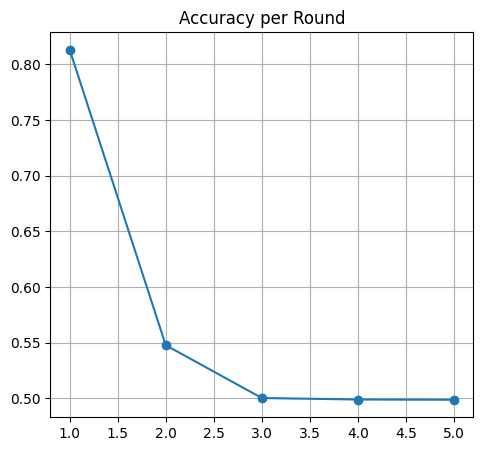

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. CNN MODEL
class BetterCNN(nn.Module):
    def __init__(self):
        super(BetterCNN, self).__init__()
        self.conv1 = nn.Conv1d(1, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(128)
        self.conv3 = nn.Conv1d(128, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(128)
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(128 * 32, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 32)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.relu(self.bn3(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        return x

# 3. TRAIN FUNCTION
def train_model(X, Y, round_num):
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.2, random_state=42
    )

    # Convert to tensors (Leave on CPU for the DataLoader)
    X_train = torch.tensor(X_train).float().unsqueeze(1)
    Y_train = torch.tensor(Y_train).float()

    # Move Test data to GPU immediately
    X_test = torch.tensor(X_test).float().unsqueeze(1).to(device)
    Y_test = torch.tensor(Y_test).float().to(device)

    train_dataset = TensorDataset(X_train, Y_train)
    train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)

    model = BetterCNN().to(device) # Move model to GPU
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0005)

    epochs = 25
    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            # Move batch to GPU
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()

    # --- SAVE THE MODEL ---
    torch.save(model.state_dict(), f"simon_cnn_r{round_num}.pth")

    model.eval()
    with torch.no_grad():
        preds = (model(X_test) > 0.5).float()
        accuracy = (preds == Y_test).float().mean().item()
        hamming = torch.mean(torch.sum(preds != Y_test, dim=1).float()).item()

    return accuracy, hamming

rounds, acc_list, ham_list = [], [], []
for r in range(1, 6):
    print(f"\n--- Training Round {r} ---")
    try:
        X = np.load(f"cnn_r{r}_X.npy")
        Y = np.load(f"cnn_r{r}_Y.npy")
        acc, ham = train_model(X, Y, r)
        print(f"Accuracy: {acc:.4f} | Hamming: {ham:.4f}")
        rounds.append(r); acc_list.append(acc); ham_list.append(ham)
    except FileNotFoundError:
        print(f"File cnn_r{r}_X.npy not found.")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(rounds, acc_list, marker='o'); plt.title("Accuracy per Round"); plt.grid()
plt.show()

Generalization

In [14]:
import random
import numpy as np

WORD_SIZE = 16

# --- SIMON LOGIC ---
def rotl(x, r):
    return ((x << r) & 0xFFFF) | (x >> (WORD_SIZE - r))

def simon_round(l, r, k):
    f = (rotl(l, 1) & rotl(l, 8)) ^ rotl(l, 2)
    return r ^ f ^ k, l

def key_schedule(key, rounds):
    return [(key >> (i % 16)) & 0xFFFF for i in range(rounds)]

def simon_encrypt(p, key, rounds):
    l, r = (p >> 16) & 0xFFFF, p & 0xFFFF
    keys = key_schedule(key, rounds)
    for i in range(rounds):
        l, r = simon_round(l, r, keys[i])
    return (l << 16) | r

def int_to_bits(x, bits=32):
    return [int(b) for b in format(x, f'0{bits}b')]

def generate_gen_dataset(samples, rounds, key):
    X, Y = [], []
    for _ in range(samples):
        p1 = random.getrandbits(32)
        p2 = random.getrandbits(32) # Independent random pair for ΔP
        c1 = simon_encrypt(p1, key, rounds)
        c2 = simon_encrypt(p2, key, rounds)
        X.append(int_to_bits(p1 ^ p2))
        Y.append(int_to_bits(c1 ^ c2))
    return np.array(X), np.array(Y)

# --- EXECUTION ---
if __name__ == "__main__":
    key = random.getrandbits(64)
    samples = 10000

    for r in range(1, 6):
        print(f"Generating Generalization dataset for round {r}...")
        X_gen, Y_gen = generate_gen_dataset(samples, r, key)

        # Saving with the '_gen' suffix required by the test script
        np.save(f"mlp_gen_r{r}_X.npy", X_gen)
        np.save(f"mlp_gen_r{r}_Y.npy", Y_gen)
        print(f"Saved: mlp_gen_r{r}_X.npy")

Generating Generalization dataset for round 1...
Saved: mlp_gen_r1_X.npy
Generating Generalization dataset for round 2...
Saved: mlp_gen_r2_X.npy
Generating Generalization dataset for round 3...
Saved: mlp_gen_r3_X.npy
Generating Generalization dataset for round 4...
Saved: mlp_gen_r4_X.npy
Generating Generalization dataset for round 5...
Saved: mlp_gen_r5_X.npy



Round      | Unseen Data Accuracy     
----------------------------------------
Round 1     | 0.8122
Round 2     | 0.5637
Round 3     | 0.4992
Round 4     | 0.5010
Round 5     | 0.4994


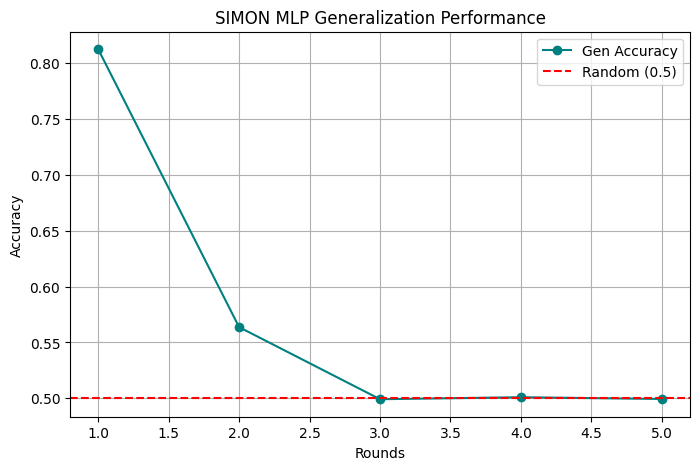

In [15]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SimonMLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(SimonMLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.layers(x)

def run_generalization_test():
    rounds = range(1, 6)
    gen_accs = []
    success_rounds = []

    print(f"\n{'Round':<10} | {'Unseen Data Accuracy':<25}")
    print("-" * 40)

    for r in rounds:
        model_path = f"simon_mlp_r{r}.pth"
        x_gen_path = f"mlp_gen_r{r}_X.npy"
        y_gen_path = f"mlp_gen_r{r}_Y.npy"

        if os.path.exists(model_path) and os.path.exists(x_gen_path):
            try:
                X_gen = np.load(x_gen_path)
                Y_gen = np.load(y_gen_path)

                X_t = torch.tensor(X_gen).float().to(device)
                Y_t = torch.tensor(Y_gen).float().to(device)

                model = SimonMLP(X_gen.shape[1], Y_gen.shape[1]).to(device)
                model.load_state_dict(torch.load(model_path, map_location=device))
                model.eval()

                with torch.no_grad():
                    preds = (model(X_t) > 0.5).float()
                    # FIX: .float() conversion before .mean()
                    acc = (preds == Y_t).float().mean().item()
                    gen_accs.append(acc)
                    success_rounds.append(r)
                    print(f"Round {r:<5} | {acc:.4f}")
            except Exception as e:
                print(f"Round {r:<5} | Error: {e}")
        else:
            print(f"Round {r:<5} | Missing .pth or .npy files")

    # Final Plotting
    if gen_accs:
        plt.figure(figsize=(8, 5))
        plt.plot(success_rounds, gen_accs, marker='o', color='teal', label='Gen Accuracy')
        plt.axhline(y=0.5, color='r', linestyle='--', label='Random (0.5)')
        plt.title("SIMON MLP Generalization Performance")
        plt.xlabel("Rounds"); plt.ylabel("Accuracy")
        plt.grid(True); plt.legend(); plt.show()

if __name__ == "__main__":
    run_generalization_test()